In [56]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing import image_dataset_from_directory
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import precision_score, recall_score, f1_score

In [8]:
# Parameters

IMG_SIZE = (224, 224)
BATCH_SIZE = 16
NUM_CLASSES = 4
EPOCHS = 10 
CLASS_NAMES = ['apple', 'banana', 'kiwi', 'orange']

In [5]:
# Load datasets

train_ds = image_dataset_from_directory(
    "fruit-dataset/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

val_ds = image_dataset_from_directory(
    "fruit-dataset/val",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

test_ds = image_dataset_from_directory(
    "fruit-dataset/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)


Found 144 files belonging to 4 classes.


E0000 00:00:1774337788.317737   22170 cuda_executor.cc:1228] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1774337788.320373   22170 gpu_device.cc:2341] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Found 28 files belonging to 4 classes.
Found 28 files belonging to 4 classes.


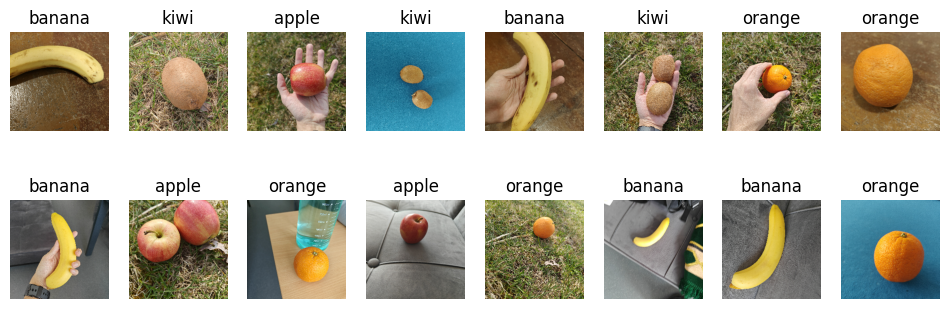

In [80]:
# Take one batch
images, labels = next(iter(train_ds))

# Preview original images
plt.figure(figsize=(12, 4))
for i in range(16):
    ax = plt.subplot(2, 8, i+1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(CLASS_NAMES[tf.argmax(labels[i])])
    plt.axis("off")

In [63]:
# Data augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.1)
])

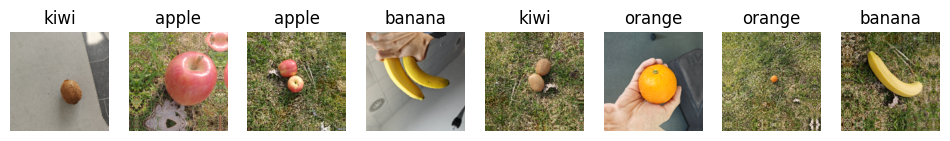

In [66]:
# Apply augmentation and preview
augmented_images = data_augmentation(images)

plt.figure(figsize=(12, 4))
for i in range(8):
    ax = plt.subplot(2, 8, i+1+8)
    plt.imshow(tf.cast(augmented_images[i], tf.uint8).numpy())
    plt.title(CLASS_NAMES[tf.argmax(labels[i])])
    plt.axis("off")

In [65]:
# Load the pretrained ResNet50 ---
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_model.trainable = False  # freeze feature extractor


In [69]:
# Build the model 

inputs = layers.Input(shape=(224,224,3))
x = data_augmentation(inputs)
x = tf.keras.applications.resnet.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
model_0 = models.Model(inputs, outputs)

In [ ]:
# Compile the model
model_0.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [72]:
# Train the model

history = model_0.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 54s 4s/step - accuracy: 0.2967 - loss: 1.7186 - val_accuracy: 0.5000 - val_loss: 1.0939
Epoch 2/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 37s 4s/step - accuracy: 0.6552 - loss: 0.9066 - val_accuracy: 0.7143 - val_loss: 0.7228
Epoch 3/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 39s 4s/step - accuracy: 0.8640 - loss: 0.5145 - val_accuracy: 0.8571 - val_loss: 0.4687
Epoch 4/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 40s 4s/step - accuracy: 0.9284 - loss: 0.3865 - val_accuracy: 0.9286 - val_loss: 0.3409
Epoch 5/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 33s 4s/step - accuracy: 0.9636 - loss: 0.2682 - val_accuracy: 0.8929 - val_loss: 0.2852
Epoch 6/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 34s 4s/step - accuracy: 0.9793 - loss: 0.1649 - val_accuracy: 0.9286 - val_loss: 0.2473
Epoch 7/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 34s 4s/step - accuracy: 0.9825 - loss: 0.1337 - val_accuracy: 0.9643 - val_loss: 0.2243
Epoch 8/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 33s 3s/step - accuracy: 0.9955 - loss: 0.0971 - val_accuracy: 0.9643 - val_loss: 0.2072
Epoch 9/

In [81]:
# Evaluation on test set
test_loss, test_acc = model_1.evaluate(test_ds)
print(f"Test Accuracy: {test_acc*100:.2f}%")

2/2 ━━━━━━━━━━━━━━━━━━━━ 9s 4s/step - accuracy: 0.2946 - loss: 2.6184
Test Accuracy: 28.57%


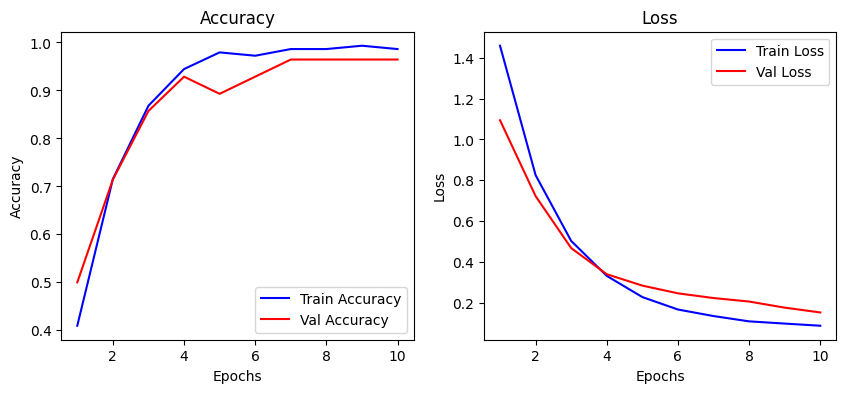

In [74]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc)+1)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(epochs_range, acc, 'b', label='Train Accuracy')
plt.plot(epochs_range, val_acc, 'r', label='Val Accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs_range, loss, 'b', label='Train Loss')
plt.plot(epochs_range, val_loss, 'r', label='Val Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [90]:
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model_0.predict(images)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Compute metrics
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000


1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step


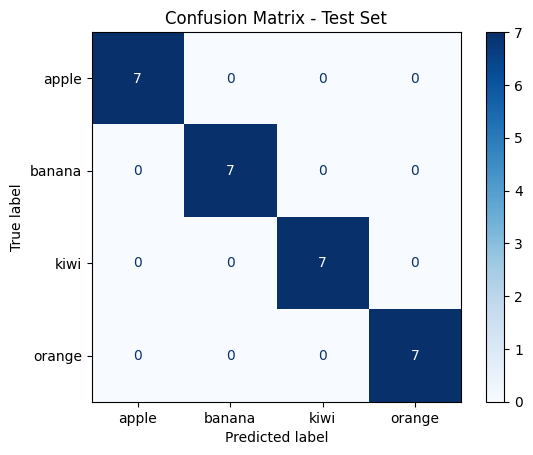

In [89]:
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model_0.predict(images)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)


cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Test Set")
plt.show()

In [82]:
inputs = layers.Input(shape=(224,224,3))
x = data_augmentation(inputs)
x = tf.keras.applications.resnet.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)  # Dropout: 30% of neurons randomly turned off

outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
model_1 = models.Model(inputs, outputs)

In [83]:
# Compile the model
model_1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [84]:
# Train the model

history = model_1.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 77s 6s/step - accuracy: 0.2831 - loss: 1.5344 - val_accuracy: 0.4643 - val_loss: 1.2041
Epoch 2/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 41s 4s/step - accuracy: 0.4748 - loss: 1.1349 - val_accuracy: 0.6071 - val_loss: 0.9285
Epoch 3/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 49s 5s/step - accuracy: 0.6608 - loss: 0.8138 - val_accuracy: 0.6786 - val_loss: 0.7545
Epoch 4/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 58s 6s/step - accuracy: 0.7870 - loss: 0.5486 - val_accuracy: 0.7500 - val_loss: 0.6386
Epoch 5/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 46s 5s/step - accuracy: 0.8840 - loss: 0.4359 - val_accuracy: 0.7500 - val_loss: 0.5543
Epoch 6/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 39s 4s/step - accuracy: 0.8664 - loss: 0.4251 - val_accuracy: 0.8214 - val_loss: 0.4883
Epoch 7/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 36s 4s/step - accuracy: 0.9288 - loss: 0.2889 - val_accuracy: 0.8571 - val_loss: 0.4602
Epoch 8/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 35s 4s/step - accuracy: 0.9516 - loss: 0.2346 - val_accuracy: 0.8571 - val_loss: 0.3881
Epoch 9/

In [86]:
# Evaluation on test set
test_loss, test_acc = model_1.evaluate(test_ds)
print(f"Test Accuracy: {test_acc*100:.2f}%")

2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 3s/step - accuracy: 0.9762 - loss: 0.1182
Test Accuracy: 96.43%


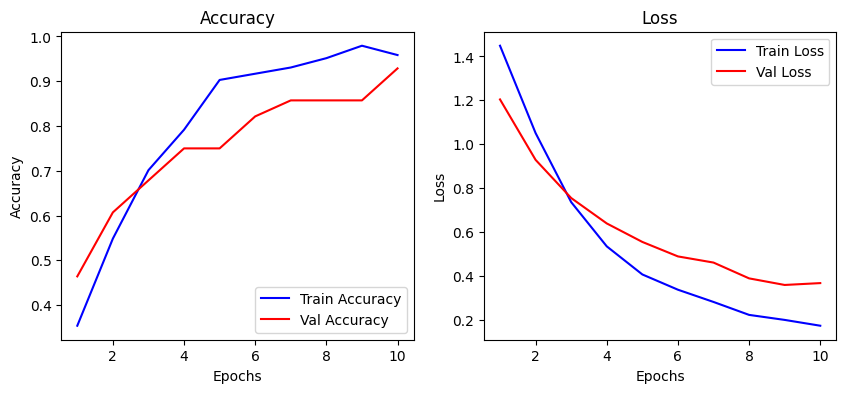

In [85]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc)+1)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(epochs_range, acc, 'b', label='Train Accuracy')
plt.plot(epochs_range, val_acc, 'r', label='Val Accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs_range, loss, 'b', label='Train Loss')
plt.plot(epochs_range, val_loss, 'r', label='Val Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [88]:
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model_1.predict(images)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Compute metrics
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
Precision: 0.9688
Recall: 0.9643
F1 Score: 0.9641


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


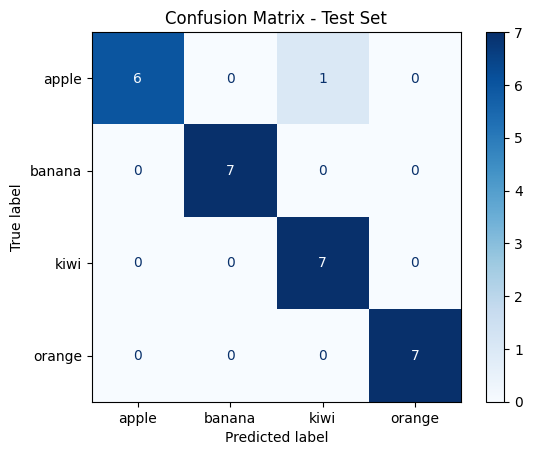

In [91]:
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model_1.predict(images)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)


cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Test Set")
plt.show()

In [93]:
inputs = layers.Input(shape=(224,224,3))
x = data_augmentation(inputs)
x = tf.keras.applications.resnet.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(64, activation='relu')(x)
x = layers.Dense(32, activation='relu')(x)
x = layers.Dropout(0.3)(x)  # Dropout: 30% of neurons randomly turned off

outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
model_2 = models.Model(inputs, outputs)

In [94]:
# Compile the model
model_2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [95]:
# Train the model

history = model_2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 75s 6s/step - accuracy: 0.3229 - loss: 1.5736 - val_accuracy: 0.5357 - val_loss: 1.1561
Epoch 2/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 41s 4s/step - accuracy: 0.4483 - loss: 1.2219 - val_accuracy: 0.7143 - val_loss: 0.9217
Epoch 3/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 39s 4s/step - accuracy: 0.5186 - loss: 1.0291 - val_accuracy: 0.6786 - val_loss: 0.8064
Epoch 4/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 40s 4s/step - accuracy: 0.6764 - loss: 0.7999 - val_accuracy: 0.7500 - val_loss: 0.7430
Epoch 5/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 36s 4s/step - accuracy: 0.6937 - loss: 0.7707 - val_accuracy: 0.7500 - val_loss: 0.6808
Epoch 6/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 32s 3s/step - accuracy: 0.7903 - loss: 0.5938 - val_accuracy: 0.7857 - val_loss: 0.6256
Epoch 7/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 33s 3s/step - accuracy: 0.7655 - loss: 0.6732 - val_accuracy: 0.8214 - val_loss: 0.5738
Epoch 8/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 32s 3s/step - accuracy: 0.8446 - loss: 0.5240 - val_accuracy: 0.8214 - val_loss: 0.5376
Epoch 9/

In [96]:
# Evaluation on test set
test_loss, test_acc = model_2.evaluate(test_ds)
print(f"Test Accuracy: {test_acc*100:.2f}%")

2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.9554 - loss: 0.2932
Test Accuracy: 96.43%


In [98]:
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model_2.predict(images)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Compute metrics
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
Precision: 0.9688
Recall: 0.9643
F1 Score: 0.9641


2026-03-24 10:44:33.179634: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


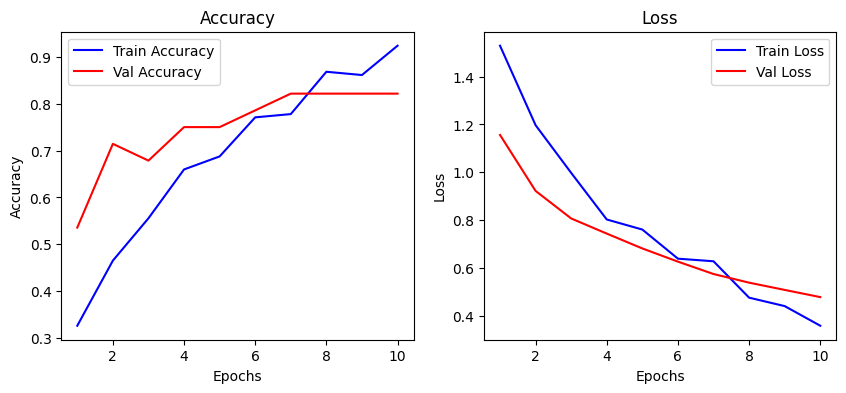

In [99]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc)+1)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(epochs_range, acc, 'b', label='Train Accuracy')
plt.plot(epochs_range, val_acc, 'r', label='Val Accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs_range, loss, 'b', label='Train Loss')
plt.plot(epochs_range, val_loss, 'r', label='Val Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


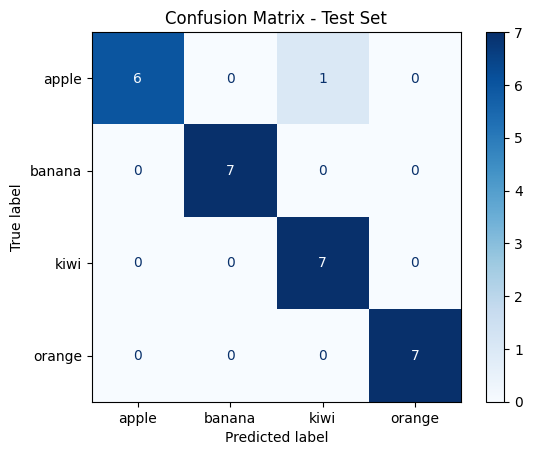

In [ ]:
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model_1.predict(images)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model_1.predict(images)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)


cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Test Set")
plt.show()
y_pred = np.array(y_pred)


cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Test Set")
plt.show()